In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')
    
os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")
matdir = os.path.join(os.getcwd(), "data", "structural_data", "Sch100")

os.chdir(matdir)

print(os.listdir())

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/whole-brain
/mnt/antares_raid/home/salfenmoser/neurolib/data/structural_data/Sch100
['NAP_002', 'NAP_003', 'NAP_018', 'NAP_032', 'NAP_024', 'NAP_009', 'NAP_027', 'NAP_022', 'NAP_020', 'NAP_011', 'NAP_016', 'NAP_028', 'NAP_014', 'NAP_010', 'NAP_025', 'NAP_005', 'NAP_012', 'NAP_026', 'NAP_029', 'NAP_035', 'NAP_036', 'NAP_033', 'NAP_013', 'NAP_007', 'NAP_031', 'NAP_015']


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from numba.typed import Dict
from numba.core import types
import pickle

from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

weights = Dict.empty(
        key_type=types.unicode_type,
        value_type=types.float64,
    )

weights["w_2"] = 0.0
weights["w_1"] = 0.0
weights["w_1T"] = 0.0
weights["w_1D"] = 1.0

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

NAP_002/SC/DTI_CM.mat
NAP_003/SC/DTI_CM.mat
NAP_005/SC/DTI_CM.mat
NAP_007/SC/DTI_CM.mat
NAP_009/SC/DTI_CM.mat
NAP_010/SC/DTI_CM.mat
NAP_011/SC/DTI_CM.mat
NAP_012/SC/DTI_CM.mat
NAP_013/SC/DTI_CM.mat
NAP_014/SC/DTI_CM.mat
NAP_015/SC/DTI_CM.mat
NAP_016/SC/DTI_CM.mat
NAP_018/SC/DTI_CM.mat
NAP_020/SC/DTI_CM.mat
NAP_022/SC/DTI_CM.mat
NAP_024/SC/DTI_CM.mat
NAP_025/SC/DTI_CM.mat
NAP_026/SC/DTI_CM.mat
NAP_027/SC/DTI_CM.mat
NAP_028/SC/DTI_CM.mat
NAP_029/SC/DTI_CM.mat
NAP_031/SC/DTI_CM.mat
NAP_032/SC/DTI_CM.mat
NAP_033/SC/DTI_CM.mat
NAP_035/SC/DTI_CM.mat
NAP_036/SC/DTI_CM.mat


In [4]:
coords = [[1.6, 0.0], [1.7, 0.1]] #1st: multistable     // 2nd: unistable synchronized

data_0_L1, data_1_L1, data_2_L1 = dict(), dict(), dict()
data_0_L1["coordinates"] = coords[0]
data_1_L1["coordinates"] = coords[0]
data_2_L1["coordinates"] = coords[1]
lng = int(4*1e3)

for d in [data_0_L1, data_1_L1, data_2_L1]:
    d["weights"] = np.zeros((100))
    d["control"] = [None] * len(data_0_L1["weights"])
    d["state"] = [None] * len(data_0_L1["weights"])
    d["init_state"] = None
    d["energy_input"] = np.zeros((len(d["weights"])))
    d["sync_cost"] = np.zeros((len(d["weights"])))
    d["state_uncontrolled"] = np.zeros((N,2,lng))

data_1_L1["weights"] *= -1

In [23]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

def plot_control(c, s, dur, dt, fat=[], filename=None, title=None):
    fig, ax = plt.subplots(2,1, figsize=(32,8), sharex=True)
    time_array = np.arange(0, dur+dt, dt)

    cmax = np.amax(np.abs(c))
    y1lim = [-cmax* 1.1, cmax* 1.1]

    for n in range(N):
        if n in fat:
            ax[0].plot(time_array, s[n,0,:], linewidth=4)
        else:
            ax[0].plot(time_array, s[n,0,:])
        ax[1].plot(time_array, c[n,0,:])

    ax[0].set_xlim(0, dur)

    ax[1].set_ylim(y1lim)

    ax[1].set_xlabel("Time")
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control")

    plt.subplots_adjust(
                    wspace=0.15,
                    hspace=0.1)
    
    fig.align_ylabels([ax[0]])
    
    if title is not None:
        fig.suptitle(title)

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight', dpi=200)

    plt.show()
    return

def get_results(d, wi, mc):
    d["control"][wi] = mc.control.copy()
    d["state"][wi] = mc.get_xs()
    d["energy_input"][wi] = cost_functions.control_strength_cost(mc.control, weights, dt)
    d["sync_cost"][wi] = (mc.compute_total_cost() - d["energy_input"][wi])/d["weights"][wi]

def dump_data():
    with open(os.path.join(datadir, 'wb_L1_cc_all_1.pickle'), 'wb') as f:
        print("dump ", os.path.join(datadir, 'wb_L1_cc_all_1.pickle'))
        pickle.dump(data_0_L1, f)

controlmat = np.zeros((N,2))
controlmat[:,0] = 1

costmat = np.zeros((N, 2))
costmat[:,0] = 1.

duration = 400.
target_period = 1

int0 = 0
int1 = None

max_cntrl = 5
pr = np.arange(0,101,1)
dt = 0.1

------------------- seed =  25


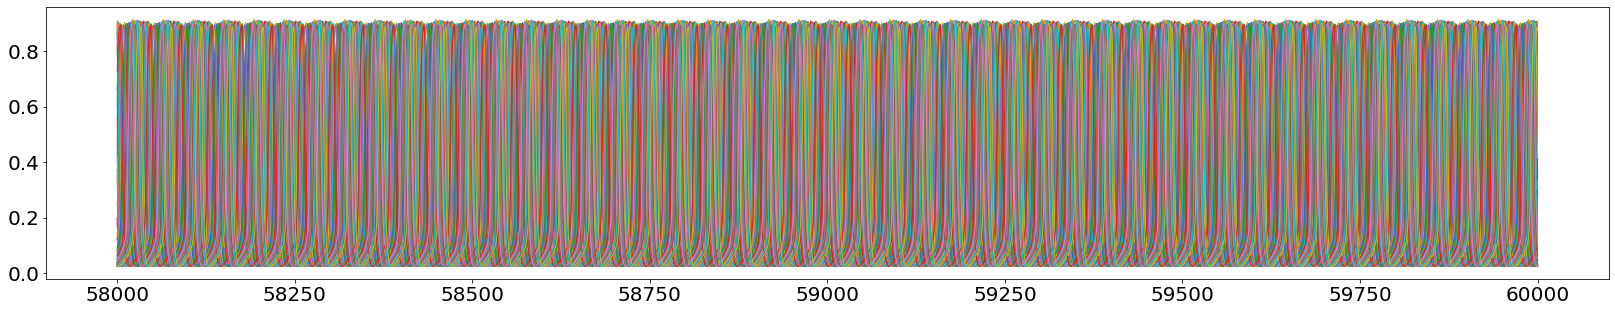

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/control/optimal_control/cost_functions.py:335: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'getmean_vt'.

For more information visit https://numba.pydata.org/numba-doc/latest/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "../../../neurolib/control/optimal_control/cost_functions.py", line 314:
@numba.njit
def getmean_vt(
^

  xmean = getmean_vt(x_sim, interval)
/mnt/antares_raid/home/salfenmoser/.pyenv/versions/miniconda3-latest/lib/python3.8/site-packages/numba/core/ir_utils.py:2067: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'var_cost'.

For more information visit https://numba.pydata.org/numba-doc/latest/reference/deprecation.html#deprecation-of-reflection-for-lis

0.08426829728692982


/mnt/antares_raid/home/salfenmoser/.pyenv/versions/miniconda3-latest/lib/python3.8/site-packages/numba/core/ir_utils.py:2067: NumbaPendingDeprecationWarning: 
Encountered the use of a type that is scheduled for deprecation: type 'reflected list' found for argument 'interval' of function 'cc_cost'.

For more information visit https://numba.pydata.org/numba-doc/latest/reference/deprecation.html#deprecation-of-reflection-for-list-and-set-types

File "../../../neurolib/control/optimal_control/cost_functions.py", line 414:
@numba.njit
def cc_cost(
^

  warnings.warn(NumbaPendingDeprecationWarning(msg, loc=loc))


-0.025985539150927384


In [6]:
point = 0
seed = [1, 25]

#for s in np.arange(0,50,1):
for i_s, s in enumerate(seed):
    
    if i_s == 0: continue

    print("------------------- seed = ", s)

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=s)
    testd = 60.*1e3     # needs to stay 60!!!!!
    dt = model.params.dt
    model.params.duration = testd
    model.params.seed = s
    setparams(model)

    #zero_input = ZeroInput().generate_input(duration=testd+model.params.dt, dt=model.params.dt)
    #input = zero_input.copy()
    #input[0,int(0.*1e3/dt):int(5.*1e3/dt)] = 1.

    #print(model.params.exc_init[0,0])

    model.params.exc_ext_baseline = data_0_L1["coordinates"][0]
    model.params.exc_inh_baseline = data_0_L1["coordinates"][1]

    #model.params.exc_ext = input
    model.run()

    plt.figure(figsize=(28,5))

    for n in range(N):
        plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
    plt.show()

    nmaxdelay = model.getMaxDelay()
    einit = np.zeros((N, nmaxdelay+1))
    iinit = np.zeros((N, nmaxdelay+1))

    state = np.zeros((N,2,lng))

    for n in range(N):
        einit[n,:] = model.exc[n,-nmaxdelay-1:]
        iinit[n,:] = model.inh[n,-nmaxdelay-1:]
        state[n,0,:] = model.exc[n, -lng:]

    if i_s == 0:
        data_0_L1["init_state"] = [einit, iinit]
        data_0_L1["state_uncontrolled"] = state.copy()
    else:
        data_1_L1["init_state"] = [einit, iinit]
        data_1_L1["state_uncontrolled"] = state.copy()

    var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(var_cost_asyn)

    cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
    print(cc_cost)

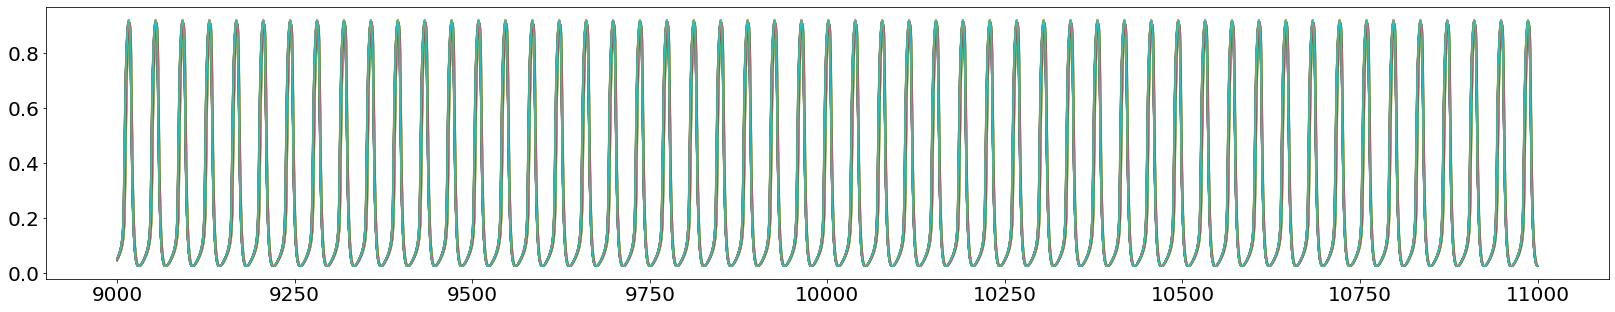

0.002332105821483664
-0.9775374609292389


In [7]:
model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
testd = 11.*1e3   ## needs to stay 11
dt = model.params.dt
model.params.duration = testd
setparams(model)

model.params.exc_ext_baseline = data_2_L1["coordinates"][0]
model.params.exc_inh_baseline = data_2_L1["coordinates"][1]

#model.params.exc_ext = input
model.run()

plt.figure(figsize=(28,5))

for n in range(N):
    plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
plt.show()

nmaxdelay = model.getMaxDelay()
einit = np.zeros((N, nmaxdelay+1))
iinit = np.zeros((N, nmaxdelay+1))

state = np.zeros((N,2,lng))

for n in range(N):
    einit[n,:] = model.exc[n,-nmaxdelay-1:]
    iinit[n,:] = model.inh[n,-nmaxdelay-1:]
    state[n,0,:] = model.exc[n, -lng:]

data_2_L1["init_state"] = [einit, iinit]
data_2_L1["state_uncontrolled"] = state.copy()

var_cost_asyn = np.sum(cost_functions.var_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(var_cost_asyn)

cc_cost = np.sum(cost_functions.cc_cost(state, costmat, [0,lng], dt)[0,:])*dt
print(cc_cost)

In [28]:
with open(os.path.join(datadir, 'wb_L1_cc_all_1.pickle'), 'rb') as f:
    data_read = pickle.load(f)

data_1_L1 = data_read

In [10]:
print(data_1_L1["weights"])

[  10.   20.   30.   40.   50.   60.   70.   80.   90.  100.  110.  120.
  130.  140.  150.  160.  170.  180.  190.  200.  210.  220.  230.  240.
  250.  260.  270.  280.  290.  300.  310.  320.  330.  340.  350.  360.
  370.  380.  390.  400.  410.  420.  430.  440.  450.  460.  470.  480.
  490.  500.  510.  520.  530.  540.  550.  560.  570.  580.  590.  600.
  610.  620.  630.  640.  650.  660.  670.  680.  690.  700.  710.  720.
  730.  740.  750.  760.  770.  780.  790.  800.  810.  820.  830.  840.
  850.  860.  870.  880.  890.  900.  910.  920.  930.  940.  950.  960.
  970.  980.  990. 1000.]


In [9]:
data_1_L1["weights"][0] = 10.
for n in range(N-1):
    data_1_L1["weights"][n+1] = data_1_L1["weights"][n] + 10.

In [18]:
def optimize_model(model, step_exp_array, wi, it, data):
    for k in step_exp_array:
        model.zero_step_encountered = False
        model.step = 10.**(k)
        model.optimize(it)
        
        get_results(data, wi, model)
        dump_data()

------------------------------------------------------------ wi =  0 10.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.17179504134783802
Final cost : -0.17179504134783802
Compute control for a deterministic system
Cost in iteration 0: -0.17179504134783802
Cost in iteration 1: -0.17179504134783802
Converged in iteration 1 with cost -0.17179504134783802
Final cost : -0.17179504134783802
get results
Compute control for a deterministic system
Cost in iteration 0: -0.17179504134783802
Cost in iteration 1: -0.17179504134783802
Converged in iteration 1 with cost -0.17179504134783802
Final cost : -0.17179504134783802
get results
max node ind =  0


<ipython-input-17-308185f3f7d8>:26: UserWarning: Attempting to set identical bottom == top == -0.0 results in singular transformations; automatically expanding.
  ax[1].set_ylim(y1lim)


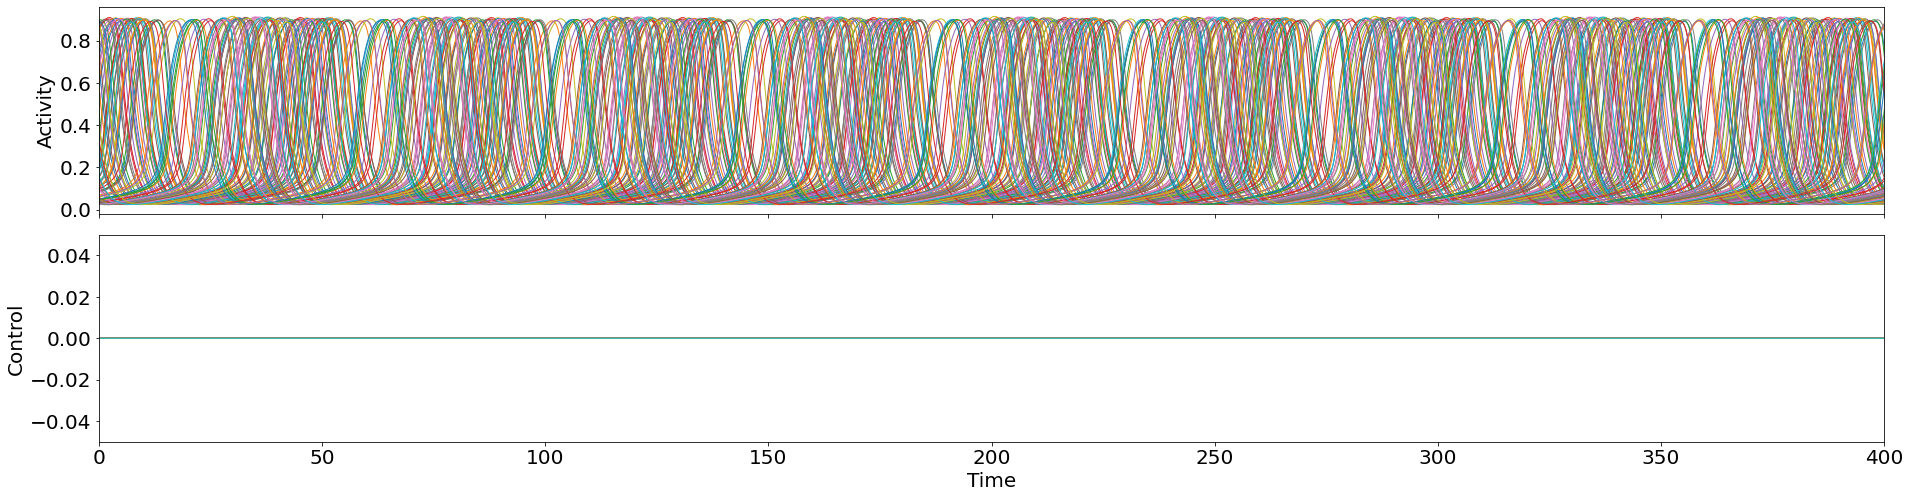

------------------------------------------------------------ wi =  2 30.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.5153851240435157
Final cost : -0.5153851240435157
Compute control for a deterministic system
Cost in iteration 0: -0.5153851240435157
Cost in iteration 1: -0.5153859370584917
Cost in iteration 2: -0.5153862972181084
Final cost : -0.5153862972181084
get results
Compute control for a deterministic system
Cost in iteration 0: -0.5153862972181084
Cost in iteration 1: -0.578599864338231
Cost in iteration 2: -0.5881212704803623
Final cost : -0.5881212704803623
get results
max node ind =  17


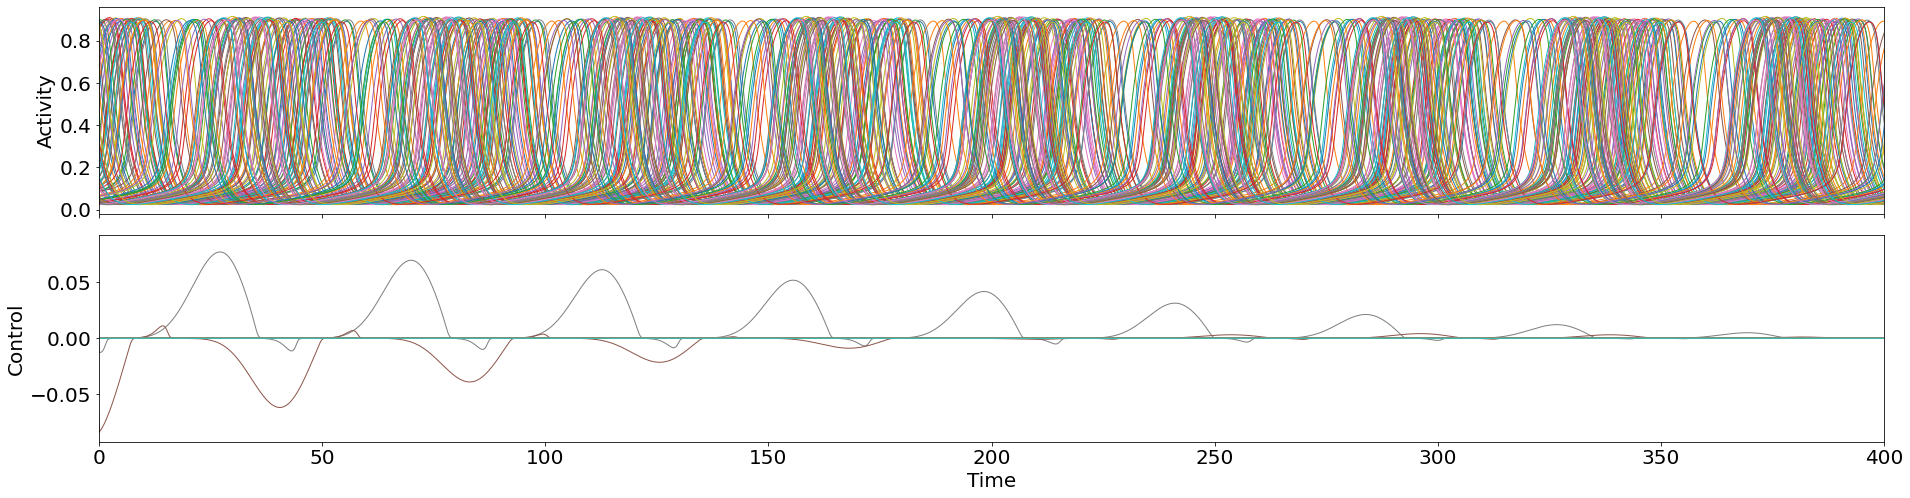

------------------------------------------------------------ wi =  4 50.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: -0.8589752067391934
Final cost : -0.8589752067391934
Compute control for a deterministic system
Cost in iteration 0: -0.8589752067391934
Cost in iteration 1: -0.8589803194523272


KeyboardInterrupt: 

In [22]:
it = 2
d = data_1_L1

for wi in np.arange(0,8,2):
    print("------------------------------------------------------------ wi = ", wi, d["weights"][wi])

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = d["init_state"][0]
    model.params.inh_init = d["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  d["coordinates"][0]
    model.params["inh_ext_baseline"] =  d["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_cc"] = d["weights"][wi]    
    model_controlled.maximum_control_strength = max_cntrl
    
    if type(d["control"][wi]) != type(None):
        model_controlled.control = d["control"][wi].copy()
        model_controlled.update_input()

    model_controlled.channelwise_optimization = True
    model_controlled.optimize(0)

    for j in range(1):
        model_controlled.grad_method = 0
        optimize_model(model_controlled, [-6, 0], wi, it, d)
        #optimize_model(model_controlled, [-6, 0, 6, -2], wi, it)
        #model_controlled.grad_method = 1
        #optimize_model(model_controlled, [-6, 0, 6, -2], wi, it)
    
    maxnodeind = np.argmax(np.sum(np.sum(d["control"][wi]**2, axis=2), axis=1))
    print("max node ind = ", maxnodeind)
    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, filename=None, title=None)

In [30]:
os.chdir(datadir)
print(os.listdir())


dump_data()

['B_sync_var_DS1.jpg', 'B_sync_var_DS0.jpg', 'sc_cd_2_L1.jpg', 'linear_cd_0_L1.jpg', 'phases_B_CC_E2.jpg', 'prc.jpg', 'A_desync_cc_DS1.jpg', '1_sc_cd_2_L1.jpg', 'times_input_all_L1.jpg', 'A_desync_var_E2.jpg', '1_sc_cd_1_L1.jpg', 'whole-brain-data_L1.ipynb', 'whole-brain-data_L1_var_all-Copy2.ipynb', 'whole-brain-eval_all.ipynb', 'phases_A_VAR_E2.jpg', 'B_desync_cc_E2.jpg', '2_sc_cd_2_L1.jpg', 'A_desync_cc_E0.jpg', 'linear_sc_2_L1.jpg', 'B_desync_cc_DS0.jpg', 'linear_sc_0_L1.jpg', 'sc_cd_1.jpg', 'whole-brain-data_L1_cc_all_0-Copy1.ipynb', 'meanOC_L1.jpg', 'A_desync_cc_E1.jpg', 'B_desync_var_E0.jpg', 'phases_syncB_CC_E2.jpg', 'linear_sc_L1.jpg', 'sc_cd_2.jpg', 'role_nodes_conn.jpg', 'A_desync_cc_E.jpg', 'wc_phase_shift.ipynb', 'boxplots_desync_phase.jpg', 'B_sync_var_E0.jpg', 'B_desync_cc_E0.jpg', 'wb_L1_all_2.pickle', 'phases_B_CC_E0.jpg', 'phases_A_CC_E2.jpg', 'cd_cd_1.jpg', 'sc_cd_sync_var.jpg', 'wb_L1_all_1.pickle', 'wb_L1_cc_all_1.pickle', 'B_desync_cc_DS1.jpg', 'B_desync_cc_DS.jpg